In [1]:
import zipfile
with zipfile.ZipFile("archive.zip","r") as z:
  z.extractall("data")

print('HAZIRDIR!')

HAZIRDIR!


In [2]:
import pandas as pd
train = pd.read_csv("data/fake_news_train.csv")
test = pd.read_csv("data/fake_news_test.csv")
print("Train:", train.shape)
print("Test", test.shape)
print(train['label'].value_counts())

Train: (5000, 2)
Test (1000, 2)
label
Real    2502
Fake    2498
Name: count, dtype: int64


In [3]:
train.head()

,text,label
0,Agent every development say. Claim says aliens...,Fake
1,Beautiful instead ahead despite measure ago cu...,Real
2,Everything thank serve civil institution every...,Fake
3,Behavior benefit suggest page. Claim says hidd...,Fake
4,Role movie win. Claim says hidden cities disco...,Fake


In [4]:
from sklearn.feature_extraction.text import TfidfVectorizer
vectorizer = TfidfVectorizer(max_features = 5000,stop_words = "english")
x_train = vectorizer.fit_transform(train['text']) #x = xeberin metni y = fake/real
x_test = vectorizer.transform(test['text'])
y_train = train['label']
y_test = test['label']
print("hazirdir!")

hazirdir!


In [5]:
from sklearn.linear_model import LogisticRegression
model = LogisticRegression()
model.fit(x_train,y_train)
print('model oyrendi')

model oyrendi


In [6]:
from sklearn.metrics import accuracy_score, classification_report
y_pred = model.predict(x_test)
print('Accuracy:', accuracy_score(y_test,y_pred))
print(classification_report(y_test,y_pred))

Accuracy: 1.0
              precision    recall  f1-score   support

        Fake       1.00      1.00      1.00       506
        Real       1.00      1.00      1.00       494

    accuracy                           1.00      1000
   macro avg       1.00      1.00      1.00      1000
weighted avg       1.00      1.00      1.00      1000



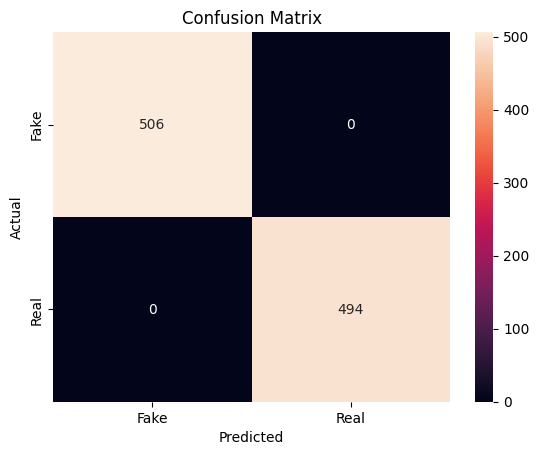

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d',
            xticklabels=['Fake','Real'],
            yticklabels=['Fake','Real'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

In [8]:
sample = ["Scientists confirm that drinking bleach cures all diseases"]
sample_vec = vectorizer.transform(sample)
print(model.predict(sample_vec))

['Fake']


In [9]:
sample = ["Scientists discover new species of fish in the Pacific Ocean"]
sample_vec = vectorizer.transform(sample)
print(model.predict(sample_vec))

['Real']
